# Exercise 6

## Exercise 6.1

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
raw_data = urlopen(url)
dataset = np.loadtxt(raw_data, delimiter=",")
print(dataset.shape)

(1372, 5)


In [16]:
X=dataset[:,[1,3]]
Y=dataset[:,4]
print(X.shape)
print(Y.shape)

(1372, 2)
(1372,)


In [17]:
fake = X[Y == 1]
real = X[Y == 0]

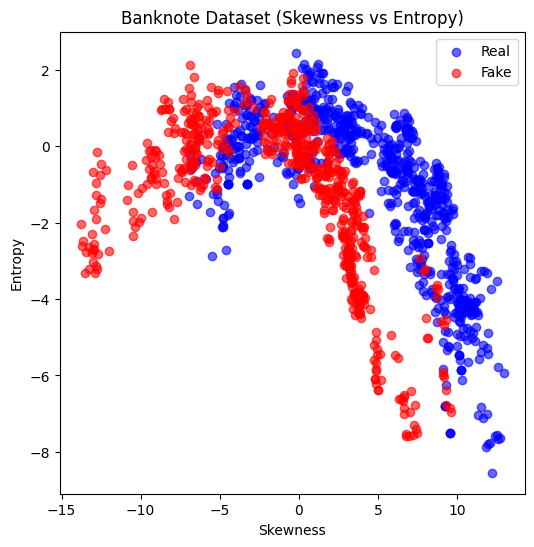

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(real[:,0], real[:,1], color='blue', label='Real', alpha=0.6)
plt.scatter(fake[:,0], fake[:,1], color='red', label='Fake', alpha=0.6)

plt.xlabel("Skewness")
plt.ylabel("Entropy")
plt.title("Banknote Dataset (Skewness vs Entropy)")
plt.legend()

plt.show()

### Can the two classes be separated by a straight line?

From the 2D plot, we can see that the two classes are not perfectly linearly separable. While there are regions where the blue and red points appear separated, there are also regions where the two classes overlap. Because of this overlap, it is not possible to completely separate the two classes using a single straight line.

### Exercise 6.2

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [ ]:
model = Sequential()
model.add(Dense(1, batch_input_shape=(None,2), activation='sigmoid'))

In [ ]:
optimizer = SGD(learning_rate=0.15)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(X, Y, epochs=400, batch_size=128, verbose=1)

Epoch 1/400
11/11 [==============================] - 1s 4ms/step - loss: 0.7064 - accuracy: 0.6363
Epoch 2/400
11/11 [==============================] - 0s 4ms/step - loss: 0.5382 - accuracy: 0.6917
Epoch 3/400
11/11 [==============================] - 0s 3ms/step - loss: 0.5205 - accuracy: 0.7318
Epoch 4/400
11/11 [==============================] - 0s 4ms/step - loss: 0.5183 - accuracy: 0.7274
Epoch 5/400
11/11 [==============================] - 0s 4ms/step - loss: 0.5148 - accuracy: 0.7303
Epoch 6/400
11/11 [==============================] - 0s 4ms/step - loss: 0.5124 - accuracy: 0.7245
Epoch 7/400
11/11 [==============================] - 0s 4ms/step - loss: 0.5135 - accuracy: 0.7230
Epoch 8/400
11/11 [==============================] - 0s 4ms/step - loss: 0.5139 - accuracy: 0.7150
Epoch 9/400
11/11 [==============================] - 0s 5ms/step - loss: 0.5142 - accuracy: 0.7179
Epoch 10/400
11/11 [==============================] - 0s 4ms/step - loss: 0.5121 - accuracy: 0.7114
Epoch 11/

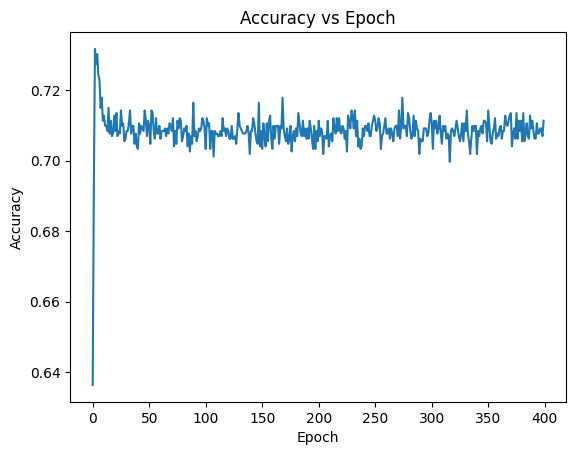

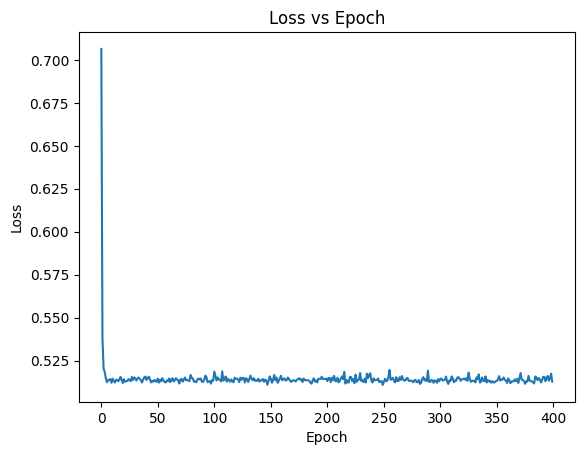

In [ ]:
# plot accuracy
plt.figure()

plt.plot(history.history['accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")

plt.show()

# plot loss
plt.figure()

plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")

plt.show()

### Is the logistic regression working well?

The logistic regression model converges during training and reaches an accuracy of about 71%. The loss decreases significantly over the epochs, which indicates that the model is learning to separate the two classes. However, since the data is not perfectly linearly separable, the model cannot perfectly classify all samples. As a result, some misclassifications remain and the accuracy does not reach 100%.

## Exercise 6.3

In [26]:
x1list = np.linspace(np.min(X[:,0])-2, np.max(X[:,0])+2, 50) # Define 50 points on the x1-axis
x2list = np.linspace(np.min(X[:,1])-2, np.max(X[:,1])+2, 50) # Define 50 points on the x2-axis

x1grid, x2grid = np.meshgrid(x1list, x2list)

In [27]:
grid_points = np.c_[x1grid.ravel(), x2grid.ravel()]

predictions = model.predict(grid_points)

Z = predictions.reshape(x1grid.shape)

79/79 [==============================] - 0s 2ms/step


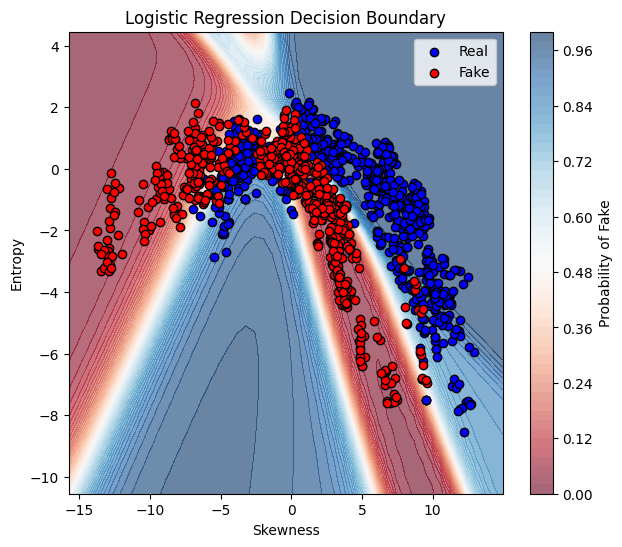

In [43]:
plt.figure(figsize=(7,6))

plt.contourf(x1grid, x2grid, Z, levels=50, cmap="RdBu", alpha=0.6)
plt.colorbar(label="Probability of Fake")

plt.scatter(real[:,0], real[:,1], color='blue', label='Real', edgecolor='k')
plt.scatter(fake[:,0], fake[:,1], color='red', label='Fake', edgecolor='k')

plt.xlabel("Skewness")
plt.ylabel("Entropy")
plt.title("Logistic Regression Decision Boundary")

plt.legend()

plt.show()

### Comment on observations

The contour plot shows the predicted probabilities of the logistic regression model across the feature space. The decision boundary appears as a straight line corresponding to a probability of approximately 0.5. The model is able to separate the two classes to some extent, but there are still regions where fake and real banknotes overlap. This leads to some misclassifications, which is expected since the data is not perfectly linearly separable.

## Exercise 6.4

In [31]:
from tensorflow.keras.utils import to_categorical 
Y_c=to_categorical(Y,2)

print(Y_c.shape)

(1372, 2)


In [32]:
model_nn = Sequential()

model_nn.add(Dense(8, activation='sigmoid', input_shape=(2,)))
model_nn.add(Dense(2, activation='softmax'))

In [33]:
optimizer = SGD(learning_rate=0.15)

model_nn.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [34]:
history_nn = model_nn.fit(X, Y_c, epochs=400, batch_size=128, verbose=1)

Epoch 1/400
11/11 [==============================] - 0s 3ms/step - loss: 0.7176 - accuracy: 0.5809
Epoch 2/400
11/11 [==============================] - 0s 2ms/step - loss: 0.6146 - accuracy: 0.7310
Epoch 3/400
11/11 [==============================] - 0s 2ms/step - loss: 0.5803 - accuracy: 0.7172
Epoch 4/400
11/11 [==============================] - 0s 2ms/step - loss: 0.5610 - accuracy: 0.7092
Epoch 5/400
11/11 [==============================] - 0s 2ms/step - loss: 0.5490 - accuracy: 0.7223
Epoch 6/400
11/11 [==============================] - 0s 3ms/step - loss: 0.5392 - accuracy: 0.7223
Epoch 7/400
11/11 [==============================] - 0s 3ms/step - loss: 0.5325 - accuracy: 0.7274
Epoch 8/400
11/11 [==============================] - 0s 3ms/step - loss: 0.5271 - accuracy: 0.7238
Epoch 9/400
11/11 [==============================] - 0s 2ms/step - loss: 0.5216 - accuracy: 0.7362
Epoch 10/400
11/11 [==============================] - 0s 3ms/step - loss: 0.5177 - accuracy: 0.7303
Epoch 11/

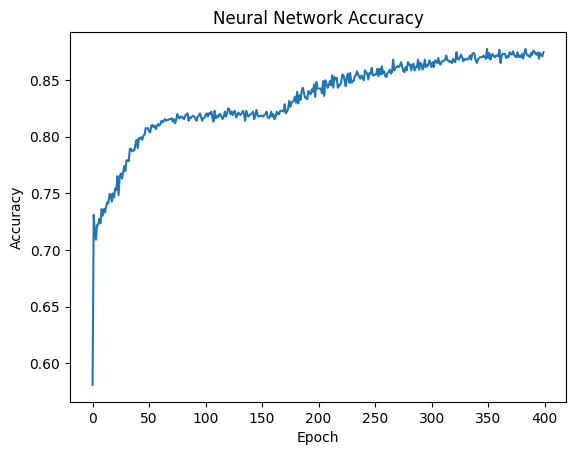

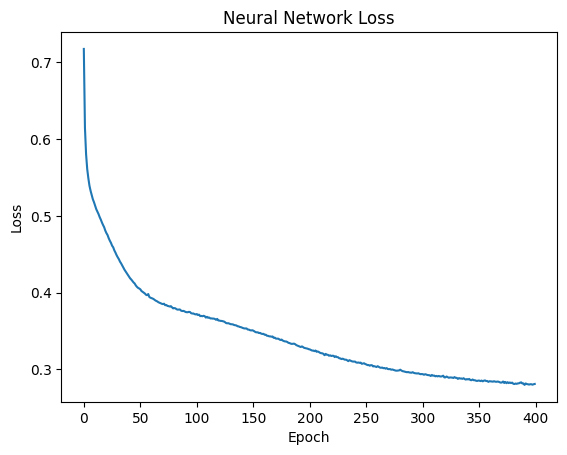

In [35]:
# plot accuracy
plt.figure()

plt.plot(history_nn.history['accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network Accuracy")

plt.show()

# plot loss
plt.figure()

plt.plot(history_nn.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Loss")

plt.show()

### Coment on your results

The neural network model converges during training and achieves a higher accuracy than the logistic regression model. The loss decreases steadily over the epochs, indicating that the network is learning an improved representation of the data. The additional hidden layer allows the model to learn non-linear decision boundaries, which better capture the structure of the dataset.

## Exercise 6.5

In [39]:
x1list = np.linspace(np.min(X[:,0])-2, np.max(X[:,0])+2, 50) # Define 50 points on the x1-axis
x2list = np.linspace(np.min(X[:,1])-2, np.max(X[:,1])+2, 50) # Define 50 points on the x2-axis

x1grid, x2grid = np.meshgrid(x1list, x2list)

In [41]:
grid_points = np.c_[x1grid.ravel(), x2grid.ravel()]

predictions = model_nn.predict(grid_points)

prob_real = predictions[:,0]

Z = prob_real.reshape(x1grid.shape)

79/79 [==============================] - 0s 1ms/step


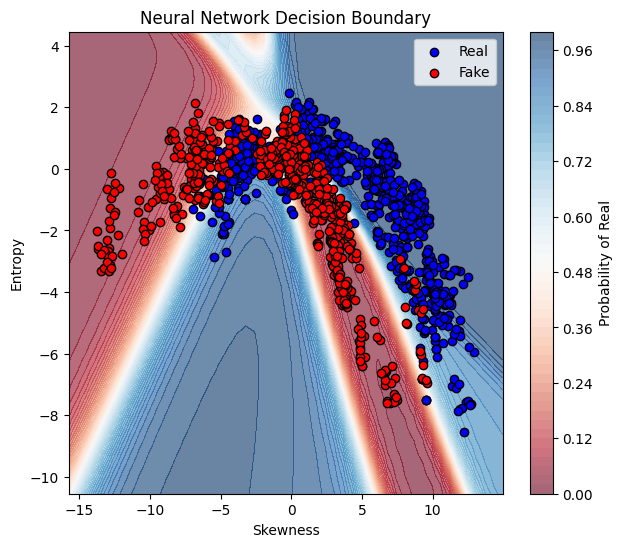

In [42]:
plt.figure(figsize=(7,6))

plt.contourf(x1grid, x2grid, Z, levels=50, cmap="RdBu", alpha=0.6)
plt.colorbar(label="Probability of Real")

real = X[Y == 0]
fake = X[Y == 1]

plt.scatter(real[:,0], real[:,1], color='blue', label='Real', edgecolor='k')
plt.scatter(fake[:,0], fake[:,1], color='red', label='Fake', edgecolor='k')

plt.xlabel("Skewness")
plt.ylabel("Entropy")
plt.title("Neural Network Decision Boundary")

plt.legend()

plt.show()

### Comment on your observations

This time, the contour plot for the neural network model shows that it learns a non-linear decision boundary that better follows the curved structure of the data. Compared to logistic regression, the boundary is no longer a straight line but instead adapts better to the distribution of the two classes. As a result, the neural network separates the fake and real banknotes more effectively, which is reflected in the higher accuracy achieved by the model.